# Module ❷: Khách hàng & Retention Analysis

**Mục tiêu**: Phân tích hành vi mua hàng lặp lại, mức độ trung thành và phân khúc khách hàng theo giá trị.

---

## 1. Setup & Load Data

In [1]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# 1. Cấu hình hiển thị Polars
pl.Config.set_tbl_cols(15)
pl.Config.set_tbl_rows(20)

# 2. Cấu hình plotting
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 3. Thêm src vào path để load DataLoader
sys.path.append(str(Path('..').resolve()))
from src.data_loader import DataLoader

loader = DataLoader()
all_dfs = loader.load_all()

orders = all_dfs['orders']
customers = all_dfs['customers']
payments = all_dfs['payments']

print(f"✅ Orders: {len(orders):,}")
print(f"✅ Customers: {len(customers):,}")
print(f"✅ Payments: {len(payments):,}")

✅ Loaded customers: 121,930 rows
✅ Loaded geography: 39,948 rows
✅ Loaded inventory: 60,247 rows
✅ Loaded order_items: 714,669 rows
✅ Loaded orders: 646,945 rows
✅ Loaded payments: 646,945 rows
✅ Loaded products: 2,412 rows
✅ Loaded promotions: 50 rows
✅ Loaded returns: 39,939 rows
✅ Loaded reviews: 113,551 rows
✅ Loaded sales: 3,833 rows
✅ Loaded sample_submission: 548 rows
✅ Loaded shipments: 566,067 rows
✅ Loaded web_traffic: 3,652 rows
✅ Orders: 646,945
✅ Customers: 121,930
✅ Payments: 646,945


## 2. Repeat Purchase Rate (Tỷ lệ mua hàng lặp lại)

Tổng số khách hàng: 90,246
Số khách hàng mua lặp lại: 67,888
Tỷ lệ mua lặp lại: 75.23%


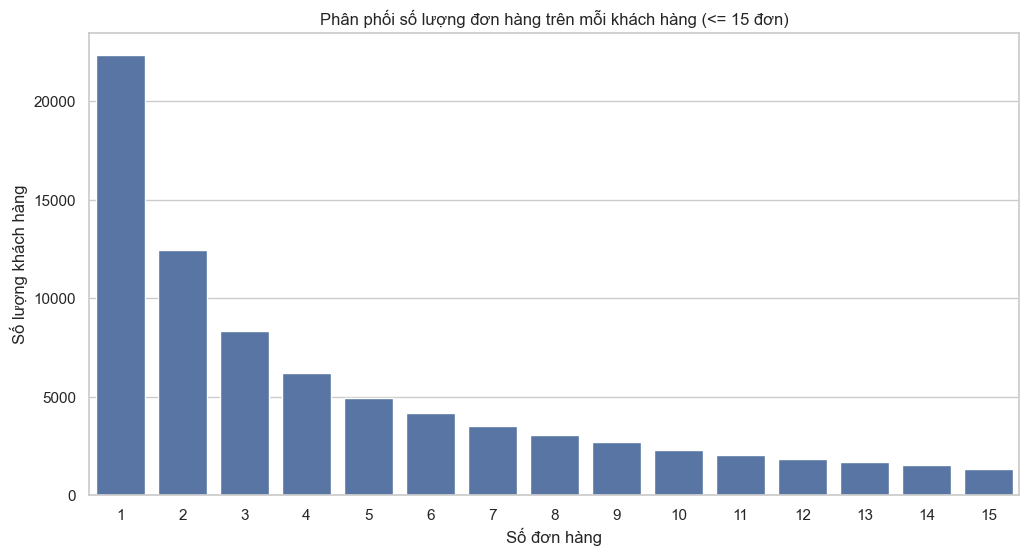

In [7]:
# 1. Đếm số đơn hàng của mỗi khách hàng
purchase_counts = orders.group_by('customer_id').agg([
    pl.count('order_id').alias('order_count')
])

# 2. Tính số lượng khách hàng mua lặp lại (>1 đơn)
total_customers = purchase_counts.height
repeat_customers = purchase_counts.filter(pl.col('order_count') > 1).height
repeat_rate = (repeat_customers / total_customers) * 100

print(f"Tổng số khách hàng: {total_customers:,}")
print(f"Số khách hàng mua lặp lại: {repeat_customers:,}")
print(f"Tỷ lệ mua lặp lại: {repeat_rate:.2f}%")

# 3. Trực quan hóa phân phối số đơn hàng
df_plot = purchase_counts.to_pandas()
# Số khách hàng mua <= 15 đơn chiếm > 99%
sns.countplot(data=df_plot[df_plot['order_count'] <= 15], x='order_count')
plt.title('Phân phối số lượng đơn hàng trên mỗi khách hàng (<= 15 đơn)')
plt.xlabel('Số đơn hàng')
plt.ylabel('Số lượng khách hàng')
plt.show()

## 3. Cohort Retention Analysis

Phân tích tỷ lệ duy trì khách hàng dựa trên tháng mua hàng đầu tiên.

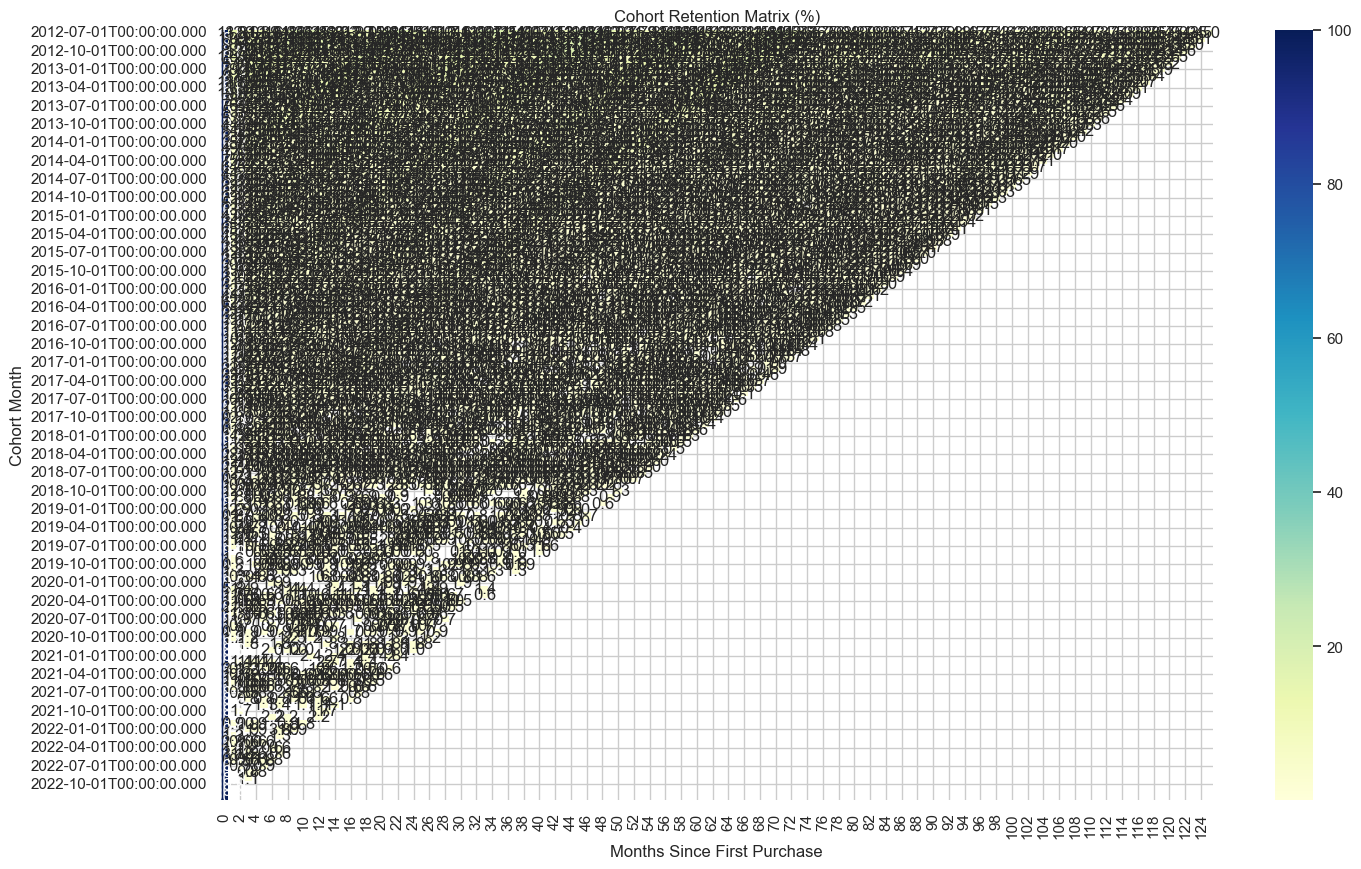

In [9]:
# 1. Xác định tháng mua hàng đầu tiên của mỗi khách hàng (Cohort Month)
cohort_data = orders.group_by('customer_id').agg([
    pl.col('order_date').min().alias('first_order_date')
])

# 2. Join lại với bảng orders
orders_cohort = orders.join(cohort_data, on='customer_id')

# 3. Tính Cohort Month và Order Month (dưới dạng yyyy-mm)
orders_cohort = orders_cohort.with_columns([
    pl.col('first_order_date').dt.truncate('1mo').alias('cohort_month'),
    pl.col('order_date').dt.truncate('1mo').alias('order_month')
])

# 4. Tính khoảng cách (index) theo tháng giữa đơn hàng và cohort
def diff_months(col_end, col_start):
    return (col_end.dt.year() - col_start.dt.year()) * 12 + (col_end.dt.month() - col_start.dt.month())

orders_cohort = orders_cohort.with_columns([
    diff_months(pl.col('order_month'), pl.col('cohort_month')).alias('cohort_index')
])

# 5. Nhóm dữ liệu để tính số lượng khách hàng active trong mỗi cohort index
cohort_counts = orders_cohort.group_by(['cohort_month', 'cohort_index']).agg([
    pl.col('customer_id').n_unique().alias('active_customers')
]).sort(['cohort_month', 'cohort_index'])

# 6. Pivot table để tạo ma trận retention
retention_matrix = cohort_counts.to_pandas().pivot(index='cohort_month', columns='cohort_index', values='active_customers')

# 7. Chuyển sang tỷ lệ %
cohort_sizes = retention_matrix.iloc[:, 0]
retention_percentage = retention_matrix.divide(cohort_sizes, axis=0) * 100

# 8. Vẽ Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(retention_percentage, annot=False, fmt='.1f', cmap='YlGnBu')
plt.title('Cohort Retention Matrix (%)')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')
plt.show()

## 4. RFM Segmentation

Phân khúc khách hàng dựa trên Recency, Frequency, và Monetary.

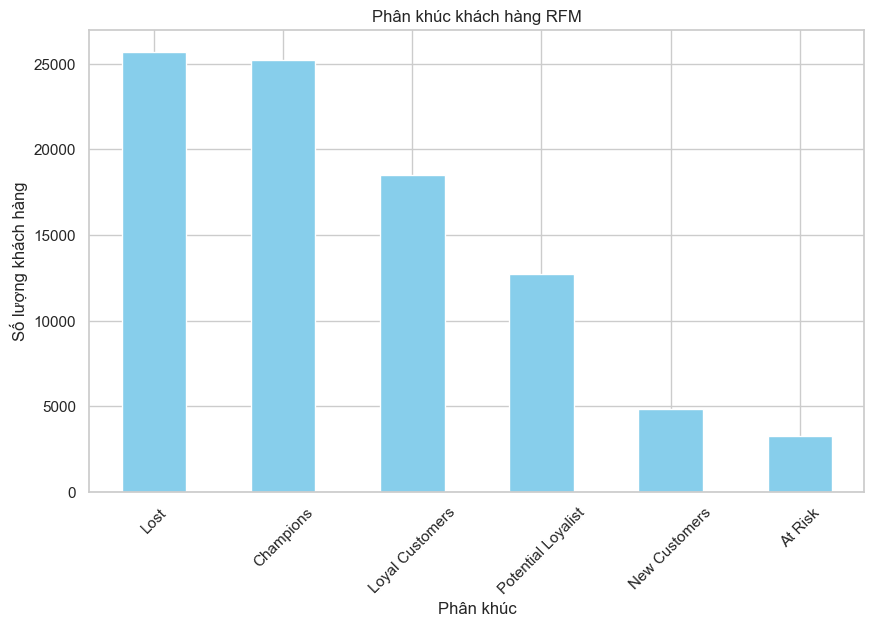

In [4]:
# 1. Chuẩn bị dữ liệu RFM
# Cần join orders với payments để có giá trị đơn hàng
order_payments = orders.join(payments, on='order_id')

current_date = orders['order_date'].max() + pl.duration(days=1)

rfm = order_payments.group_by('customer_id').agg([
    ((current_date - pl.col('order_date').max()).dt.total_days()).alias('recency'),
    pl.col('order_id').n_unique().alias('frequency'),
    pl.col('payment_value').sum().alias('monetary')
])

# 2. Tính điểm R, F, M (Quantiles)
rfm_pd = rfm.to_pandas()
rfm_pd['r_score'] = pd.qcut(rfm_pd['recency'], 5, labels=[5, 4, 3, 2, 1])
rfm_pd['f_score'] = pd.qcut(rfm_pd['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm_pd['m_score'] = pd.qcut(rfm_pd['monetary'], 5, labels=[1, 2, 3, 4, 5])

# 3. Tính RFM Score
rfm_pd['rfm_score'] = rfm_pd['r_score'].astype(str) + rfm_pd['f_score'].astype(str) + rfm_pd['m_score'].astype(str)

# 4. Phân khúc (Ví dụ đơn giản)
def segment_customer(df):
    r = int(df['r_score'])
    f = int(df['f_score'])
    if r >= 4 and f >= 4:
        return 'Champions'
    if r >= 3 and f >= 3:
        return 'Loyal Customers'
    if r >= 4 and f <= 2:
        return 'New Customers'
    if r <= 2 and f >= 4:
        return 'At Risk'
    if r <= 2 and f <= 2:
        return 'Lost'
    return 'Potential Loyalist'

rfm_pd['segment'] = rfm_pd.apply(segment_customer, axis=1)

# 5. Trực quan hóa phân khúc
segment_counts = rfm_pd['segment'].value_counts()
plt.figure(figsize=(10, 6))
segment_counts.plot(kind='bar', color='skyblue')
plt.title('Phân khúc khách hàng RFM')
plt.xlabel('Phân khúc')
plt.ylabel('Số lượng khách hàng')
plt.xticks(rotation=45)
plt.show()

## 5. Kết luận sơ bộ (Key Insights)

- **Repeat Rate**: ...
- **Retention**: Nhóm cohort tháng ... có tỷ lệ duy trì tốt nhất.
- **RFM**: Tỷ lệ khách hàng 'At Risk' là ... cần có chiến dịch Win-back.